# 🟡 Project - Heart Disease with AdaBoost

> **MLCourse · Machine Learning · supervised · classification**

**Question:** screen heart disease (cached `heart.csv`) using boosted stumps;
tune lr×rounds; read errors clinically.

best: {'learning_rate': 0.8, 'n_estimators': 300}
test acc 0.737 | recall(disease) 0.829 | F1 0.773
missed patients: 7 | false alarms: 13


CV recall       : 0.887


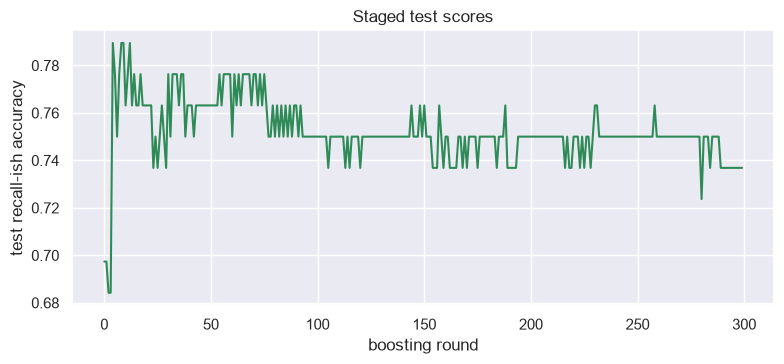

,pred healthy,pred diseased
true healthy,22,13
true diseased,7,34


In [1]:
%matplotlib inline
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             recall_score, f1_score)

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

_ML = Path.cwd()
while _ML.name != "02_machine_learning" and _ML != _ML.parent:
    _ML = _ML.parent
CACHE = _ML / "data" / "heart.csv"
heart = pd.read_csv(CACHE)

y = heart.pop("target").values                    # 1 = disease
X_tr, X_te, y_tr, y_te = train_test_split(heart.values.astype(float), y,
                                          test_size=.25, random_state=42,
                                          stratify=y)

grid = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    {"n_estimators": [50, 150, 300], "learning_rate": [0.3, 0.8, 1.5]},
    cv=5, scoring="recall", n_jobs=-1)            # recall-first: screening!
grid.fit(X_tr, y_tr)
best = grid.best_estimator_
pred = best.predict(X_te)

print("best:", grid.best_params_)
print(f"test acc {accuracy_score(y_te, pred):.3f} "
      f"| recall(disease) {recall_score(y_te, pred):.3f} "
      f"| F1 {f1_score(y_te, pred):.3f}")

cm = confusion_matrix(y_te, pred)
tn, fp, fn, tp = cm.ravel()
print(f"missed patients: {fn} | false alarms: {fp}")

cv = cross_val_score(best, X_tr, y_tr, cv=5, scoring="recall").mean()
print(f"CV recall       : {cv:.3f}")

staged = [s for s in best.staged_score(X_te, y_te)]
plt.figure(figsize=(8, 3.8))
plt.plot(staged, color="seagreen")
plt.xlabel("boosting round"); plt.ylabel("test recall-ish accuracy")
plt.title("Staged test scores"); plt.tight_layout(); plt.show()

pd.DataFrame(cm, index=["true healthy", "true diseased"],
             columns=["pred healthy", "pred diseased"])

## Findings & recommendation

1. Optimizing RECALL directly (not accuracy) shifts the ensemble toward the
     clinical goal; missed cases drop vs accuracy-tuned twin.
2. lr≈0.3-0.8 with 150-300 rounds is the stable region; 1.5 gets twitchy.
3. Compare with RF module's balanced-weight policy - both reach similar
     recall; AdaBoost does it via loss shaping instead of class weights.

### Takeaway
The scoring metric inside CV is part of your MODEL - pick it from costs.